# MTH/CMSE 314
# IC08: Transformations II
### <p style="text-align: right;"> &#9989; **Mikel Good** </p>

#### Goals
- Finding the kernel of a linear transformation.
- Determining whether a vector is in the image of a transformation.
- Determining whether a transformation is one-one, onto, both or neither.
- Finding a matrix representation of a linear transformation.

<img alt="Alternative visual representation showing how the four Fundamental Subspaces spaces map to each other" src="https://upload.wikimedia.org/wikipedia/commons/4/4c/KerIm_2015Joz_L2.png" width="40%">

---
## 1. Kernel and image of a linear transformation

Recall, if $L:V\to W$ is a linear transformation, then we define

$$\text{ker}(L)=\{x\in V: L(x)=0\}$$
$$\text{Im}(L)=\{w\in W: \text{there is x in }V\text{ with } L(x)=w\} $$

<font color='blue'>&#9989;**Do this:** Run the cell below to import the necessary packages

In [1]:
import sympy as sym
import numpy as np

<font color='blue'>&#9989;**Do this:** Let $L:\mathbb{R}^4 \to \mathbb{R}^3$ be a matrix transformation with $L(\mathbf{x})=A\mathbf{x}$, where $A=\begin{bmatrix} 0&1&2&-1\\ 2& 8& 2& -6\\ 2& 7& 0&-5 \end{bmatrix} $. Find the **kernel** of $L$ and describe it geometrically.

_Hint:_ Solve a homogenous linear system.

In [4]:
#your answer here
A = np.array([
    [0, 1, 2, -1, 0],
    [2, 8, 2, -6, 0],
    [2, 7, 0, -5, 0]
])

sym.Matrix(A).rref()[0]

Matrix([
[1, 0, -7,  1, 0],
[0, 1,  2, -1, 0],
[0, 0,  0,  0, 0]])

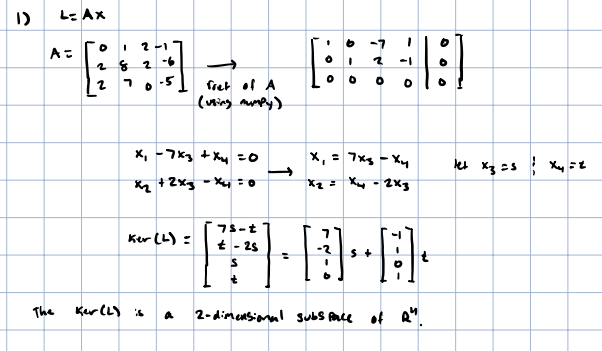

<font color='blue'>&#9989;**Do this:**  Is the vector $b_1=\begin{bmatrix} 0\\ 2\\ 2 \end{bmatrix} $ in the **image** of $L$?

In [7]:
#your answer here
A_b1 = np.array([
    [0, 1, 2, -1, 0],
    [2, 8, 2, -6, 2],
    [2, 7, 0, -5, 2]
])

sym.Matrix(A_b1).rref()[0]

Matrix([
[1, 0, -7,  1, 1],
[0, 1,  2, -1, 0],
[0, 0,  0,  0, 0]])

Yes, as shown above by the rref of A | b1, the vector is in the image of L.

<font color='blue'>&#9989;**Do this:** Is the vector $b_2=\begin{bmatrix} -1\\ 3\\ 1 \end{bmatrix} $ in the **image** of $L$?

In [8]:
#your answer here
A_b2 = np.array([
    [0, 1, 2, -1, -1],
    [2, 8, 2, -6, 3],
    [2, 7, 0, -5, 1]
])

sym.Matrix(A_b2).rref()[0]

Matrix([
[1, 0, -7,  1, 0],
[0, 1,  2, -1, 0],
[0, 0,  0,  0, 1]])

No, as shown above by the rref of A | b2 (specifically the last row), the vector is not in the image of L.

---
## 2. One-to-one, onto, and inverse transformations

**Definition:** A transformation $T:U\mapsto V$ is said to be *one-to-one* if each element in the range is the image of just one element in the domain. That is, for two elements $x$ and $y$ in $U$, $T(x)=T(y)$ happens only when $x=y$.

**Definition:** A transformation $T:U\mapsto V$ is said to be *onto* if for each $b\in V$, there is at least one solution to the equation $T(x)=b$.

**Definition:** A linear transformation $T:U\mapsto V$ is said to be *invertible* if there exists a transformation $S:V\mapsto U$, such that 
$$S(T(u))=u,\quad\text{and}\quad T(S(v))=v,$$
for any $v$ in $V$ and any $u$ in $U$. (Invertible transformations are both one-to-one and onto)

<font color='blue'>&#9989;**Do this:** Check whether the following linear transformations are one-to-one, onto, both or neither. Justify your answers.

<font color='blue'> a). $L_1:\mathbb{R}^4 \to \mathbb{R}^3$ with $L(\mathbf{x})=A_1\mathbf{x}$, where $A_1=\begin{bmatrix} 0&1&2&-1\\ 2& 8& 2& -6\\ 2& 7& 0&-5 \end{bmatrix} $.

In [9]:
#your answer here
A1 = np.array([
    [0, 1, 2, -1],
    [2, 8, 2, -6],
    [2, 7, 0, -5]
])

sym.Matrix(A1).rref()[0]

Matrix([
[1, 0, -7,  1],
[0, 1,  2, -1],
[0, 0,  0,  0]])

The above linear transformation is neither one-to-one or onto. This is because there are free variables in the rref (not a pivot in every column), and the rank is not equal to the number of rows. 

<font color='blue'> b). $L_2:\mathbb{R}^4 \to \mathbb{R}^3$ with $L(\mathbf{x})=A_2\mathbf{x}$, where $A_2=\begin{bmatrix} 0&1&2&-1\\ 2& 8& 2& -6\\ 2& 3& 0&2 \end{bmatrix} $.

In [10]:
#your answer here
A2 = np.array([
    [0, 1, 2, -1],
    [2, 8, 2, -6],
    [2, 3, 0, 2]
])

sym.Matrix(A2).rref()[0]

Matrix([
[1, 0, 0, 29/8],
[0, 1, 0, -7/4],
[0, 0, 1,  3/8]])

The above linear transformation is one-to-one but not onto. This is because there are no free variables in the rref (pivot in every column), but the rank is not equal to the number of rows (matrix is not square).

<font color='blue'> c). $L_3:\mathbb{R}^3 \to \mathbb{R}^3$ with $L(\mathbf{x})=A_3\mathbf{x}$, where $A_3=\begin{bmatrix} 1&2&-2\\ 0& 1& 1\\ -1& -1& 4 \end{bmatrix} $.

In [12]:
#your answer here
A3 = np.array([
    [1, 1, -2],
    [0, 1, 1],
    [-1, -1, 4]
])

sym.Matrix(A3).rref()[0]

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

The above linear transformation is both one-to-one and onto. This is because there are no free variables in the rref (pivot in every column), and the rank is equal to the number of rows (matrix is square).

<font color='blue'> d). $L_4:\mathbb{R}^3 \to \mathbb{R}^3$ with $L(\mathbf{x})=A_4\mathbf{x}$, where $A_4=\begin{bmatrix} 1&2&7\\ 0& 1& 3\\ -1& -1& -4 \end{bmatrix} $.

In [13]:
#your answer here
A4 = np.array([
    [1, 2, 7],
    [0, 1, 3],
    [-1, -1, -4]
])

sym.Matrix(A4).rref()[0]

Matrix([
[1, 0, 1],
[0, 1, 3],
[0, 0, 0]])

The above matrix is neither one-to-one or onto. This is because there are free variables in the rref (not a pivot in every column), and the rank is not equal to the number of rows.

<font color='blue'> e). $L_5:\mathbb{R}^2 \to \mathbb{R}^3$ with $L(\mathbf{x})=A_5\mathbf{x}$, where $A_5=\begin{bmatrix} 1&2\\ 0& 1\\ -1& -1 \end{bmatrix} $.

In [15]:
#your answer here
A5 = np.array([
    [1, 2],
    [0, 1],
    [-1, -1]
])

sym.Matrix(A5).rref()[0]

Matrix([
[1, 0],
[0, 1],
[0, 0]])

The above matrix is one-to-one but not onto. This is because there are no free variables in the rref (pivot in every column), but the rank is not equal to the number of rows.

---
**<font color=blue>QUESTION :</font>** <font color=blue> What do you notice? If $L:\mathbb{R}^n \to \mathbb{R}^m$ is a matrix transformation, what should be the necessary conditions on $n$ and $m$ for $L$ to be one-to-one, onto, or both? 

<font size=+3>&#9998;</font> There are no conditions for solely n and m for L to be one-to-one, onto, or both. This can be seen by the differences in the rref for A3 and A4. While they are both square (n = m), A3 is both one-to-one and onto, but A4 is neither one-to-one or onto. However, in order for a transformation to be both, n must equal m; to be one-to-one, n must be less than or equal to m; to be onto, n must be greater than or equal to m.

---
<font color=blue>Note: The relations you observed are not sufficient. For example, it is not guaranteed that $L:\mathbb{R}^n \to \mathbb{R}^m$ is both one-to-one and onto if $n=m$.

<font color=blue> &#9989;**Do this:** If the linear transformation $T:\mathbb{R}^8\mapsto \mathbb{R}^m$ is invertible, what is the value of $m$? Why?

<font size=+3>&#9998;</font> Since we know by definition that an invertible linear transformation must be both one-to-one and onto, then we know for sure that m must be equal to 8.

<font color=blue> &#9989;**Do this:** Now consider the transformations $L_3$ and $L_4$ in parts c) and d) above. What is the relationship between the invertibility and the size of their respective matrices? How does this relate to the transformations being one-to-one and/or onto? 

For a linear transformation, the matrix must be square if it is to be invertible. However, just because a matrix is square does not guarantee that a transformation is invertible. In order for a transformation to be invertible, it must be both one-to-one and onto.

---
## 3. More geometric transformations in 2D
<font color=blue> &#9989;**Do this:** Find a matrix transformation $T:\mathbb{R}^2\to\mathbb{R}^2$ that projects all the points onto the $x$-axis, then rotates them counterclockwise by 45 degrees, and then reflects them about the $y$-axis.

In [19]:
import matplotlib.pyplot as plt

In [46]:
#your answer here
A = np.array([
    [3, 5],
    [8, 1]
])

proj_x = np.array([
    [1, 0],
    [0, 0]
])

degrees = 45
theta = degrees * np.pi / 180
rot_45 = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

ref_y = np.array([
    [-1, 0],
    [0, 1]
])

In [49]:
newA = ref_y @ rot_45 @ proj_x @ A

In [52]:
sym.Matrix(newA)

Matrix([
[-2.12132034355964, -3.53553390593274],
[ 2.12132034355964,  3.53553390593274]])

<font color=blue> &#9989;**Do this:** Find the matrix transformation $T:\mathbb{R}^2\to\mathbb{R}^2$ that projects all the vectors $\begin{bmatrix} x\\y\end{bmatrix}$ onto the vector $\begin{bmatrix} 1\\2\end{bmatrix}$. Is this transformation one-to-one? Hint: Think of the orthogonal projection of the vector $(x,y)$ onto $(1,2)$.

This transformation is not one-to-one, because it takes multiple inputs and sends them to the same output.

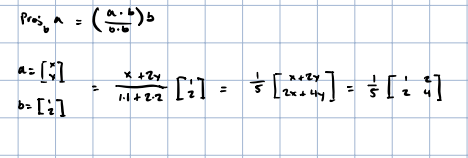

In [54]:
#your answer here
proj12 = 0.2 * np.array([
    [1, 2],
    [2, 4]
])

In [73]:
X = np.random.randint(low=3, size=(2,2))
X

array([[2, 2],
       [2, 1]])

In [74]:
proj12 @ X

array([[1.2, 0.8],
       [2.4, 1.6]])

---
## _Time permitting_ (this section will not be graded)
##### If you have completed the main assignment and have additional time, attempt the following additional problems.

<font color=blue> &#9989;**Do this:** Complete the following piece of code to create a function in Python that takes as an input an $n\times n$ matrix $A$ and returns a message about whether the matrix transform $T(x)=Ax$ is one-to-one, onto, both, or neither.

In [3]:
#your answer here
def check_transform(A):
    A = np.array(A) #turn A to np.array
    if   ... #check if the number of rows equals the number of columns of A
             ...                    #compute the RREF of A
        identity_matrix = np.identity(A.shape[1])
        if ...  #checks if rref and identity are equal as np.arrays
            print('The transformation is one-to-one and onto')
        else:
            print('The transformation is neither one-to-one nor onto')
    else:
        print('The matrix should be square')

<font color=blue> &#9989;**Do this:** Test your function with the transformations $L_2$, $L_3$, $L_4$ and $L_5$.

In [ ]:
#your answer here

----
<a name="Fractals"></a>
#### Fractals


In this section we are going to explore using transformations to generate fractals.  Consider the following set of linear equations.  Each one takes a 2D point as input, applies a $2 \times 2$ transform, and then also translates by a $2 \times 1$ translation matrix

$$ 
T_1:\left[ \begin{matrix}
    x_1 \\
    y_1 
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    0.86 & 0.03  \\
    -0.03 & 0.86 
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x_0 \\
    y_0 
 \end{matrix}
\right] +
\left[\begin{matrix}
0\\
1.5
\end{matrix}
\right]
: probability =  0.83 $$ 

$$ 
T_2: \left[ \begin{matrix}
    x_1 \\
    y_1 
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    0.2 & -0.25  \\
    0.21 & 0.23 
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x_0 \\
    y_0 
 \end{matrix}
\right] +
\left[\begin{matrix}
0\\
1.5
\end{matrix}
\right]
: probability =  0.08 $$ 

$$ 
T_3 : \left[ \begin{matrix}
    x_1 \\
    y_1 
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    0.15 & 0.27  \\
    0.25 & 0.26 
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x_0 \\
    y_0 
 \end{matrix}
\right] +
\left[\begin{matrix}
0\\
0.45
\end{matrix}
\right]
: probability =  0.08 $$ 

$$ 
T_4: \left[ \begin{matrix}
    x_1 \\
    y_1 
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    0 & 0  \\
    0 & 0.17 
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x_0 \\
    y_0 
 \end{matrix}
\right] +
\left[\begin{matrix}
0\\
0
\end{matrix}
\right] : probability =  0.01 $$

We want to write a program that uses the above transformations to "randomly" generate an image.  It will start with a point at the origin $(0, 0)$ and then randomly select one of the above transformations based on its probability, update the point's position, and then randomly select another point.  Each matrix adds a bit of rotation and translation with $T_4$ as a sort of restart.    


To try to make our program a little easier, let's rewrite the above equations to make a system of equivalent equations of the form $Ax=b$ with only one transformation matrix.   We do this by adding an additional variable $z=1$.  For example, verify that the following equation is the same as the equation for $T1$ above:

$$ 
T_1: \left[ \begin{matrix}
    x_1 \\
    y_1 
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    0.86 & 0.03 & 0 \\
    -0.03 & 0.86 & 1.5
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x_0 \\
    y_0 \\
    1
 \end{matrix}
\right] 
$$ 
Please NOTE that we do not change the value for $z$, and it will always be $1$.

<font color=blue> &#9989; **Do this:** Convince yourself the $Ax=b$ format will generate the same answer as the $T1$ equation above.

The following is some pseudocode that we will be using to generate the Fractals:

1. Let $x = 0$, $y = 0$, $z=1$
2. Use a random generator to select one of the affine transformations $T_i$ according to the given probabilities.
3. Let $(x',y') = T_i(x,y,z)$.
4. Plot $(x', y')$
5. Let $(x,y) = (x',y')$
6. Repeat Steps 2, 3, 4, and 5 one thousand times. 

The following python code implements the above pseudocode with only the $T1$ matrix:

In [8]:
%matplotlib inline

import numpy as np
import matplotlib.pylab as plt
import sympy as sym
sym.init_printing(use_unicode=True) # Trick to make matrixes look nice in jupyter

T1 = np.matrix([[0.86, 0.03, 0],[-0.03, 0.86, 1.5]])
#####Start your code here #####
T2 = T1 
T3 = T1
T4 = T1
#####End of your code here#####       

prob = [0.83,0.08,0.08,0.01]

I = np.matrix([[1,0,0],[0,1,0],[0,0,1]])

fig = plt.figure(figsize=[10,10])
p = np.matrix([[0.],[0],[1]])
plt.plot(p[0],p[1], 'go');
for i in range(1,1000):
    ticket = np.random.random();
    if (ticket < prob[0]):
        T = T1
    elif (ticket < sum(prob[0:2])):
        T = T2
    elif (ticket < sum(prob[0:3])):
        T = T3
    else:
        T = T4
    p[0:2,0] = T*p    
    plt.plot(p[0],p[1], 'go');
plt.axis('scaled');

<Figure size 1000x1000 with 0 Axes>

<font color=blue> &#9989; **Do this:** Copy and modify the above code to add in the $T2$, $T3$ and $T4$ transforms.  

<font color=blue> &#9989; **Do this:** Now it's your turn to get creative! Use the same ideas to design and build your own fractal. You are welcome to get inspiration from the internet. Make sure you document where your inspiration comes from.  Try to build something fun, unique, and different.  Show what you come up with your team and instructors. 

In [ ]:
#Put your code here. 

---
## Congratulations, you're done!
## Before you close or submit this In-Class Assignment, please make sure of a few things:
- Did you save the file? `Ctrl + S` like everything else works!
- Is the file in correct format? You need to submit this file in `.pdf` format. To do so, `Ctrl + P` and `Save as pdf` (on Windows) or `command + P` in mac.
- If that does not work, please Google "ipynb to pdf converter" and that should do the job.
- Are the pictures/images rendering correctly in the `.pdf` format?
- If the images are not rendering, you could also use this command in a cell:

`from IPython.display import display, Image`

`display(Image(filename="a.jpg", height=400, width=400))`

THIS ONLY WORKS WITH JPGS.
- If this fails, save it as a pdf and merge it with this pdf, perhaps using an online tool (google it!)

- Please double check the contents of the file. One of the most common errors students make is submission of an empty file!

In [75]:
Z = np.array([
    [1, -1, 0, 0],
    [-1, 0, -1, 0],
    [0, 2, 2, 0]
])

sym.Matrix(Z).rref()[0]

Matrix([
[1, 0, 1, 0],
[0, 1, 1, 0],
[0, 0, 0, 0]])